In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler #?
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Carga de datos
try:
    df = pd.read_csv('~/Proyectos/HARS/Datasets/yeast1.csv')
except FileNotFoundError:
    df = pd.read_csv('yeast1.csv')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Determinar ratio original
clases, conteos = np.unique(y_train, return_counts=True)
clase_min = clases[np.argmin(conteos)]
ratio_original = conteos[np.argmin(conteos)] / conteos[np.argmax(conteos)]

In [8]:
def calcular_gps(y_true, y_pred):
    """
    Calcula un GPS simplificado basado en la Media Armónica de Sensibilidad y Especificidad,
    para penalizar los desequilibrios entre los Falsos Positivos y Falsos Negativos.
    """
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        
        if (sensibilidad + especificidad) == 0:
            return 0.0
        return 2 * (sensibilidad * especificidad) / (sensibilidad + especificidad)
    return 0.0

# Función Evaluadora de Rendimiento
def evaluar_rendimiento_predictivo(X_tr, y_tr):
    rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_test)
    
    gmean = geometric_mean_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    gps = calcular_gps(y_test, y_pred)
    
    return gmean, mcc, gps

In [9]:
ratios_a_probar = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print("Iniciando evaluación predictiva paralela (G-mean, MCC, GPS)...")

# Evaluar Original (Baseline)
gmean_orig, mcc_orig, gps_orig = evaluar_rendimiento_predictivo(X_train, y_train)
resultados = [{
    'Ratio SMOTE': round(ratio_original, 3),
    'G-mean': gmean_orig,
    'MCC': mcc_orig,
    'GPS': gps_orig
}]

# Iterar sobre SMOTE
for r in ratios_a_probar:
    smote = SMOTE(sampling_strategy=r, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    
    g, m, gp = evaluar_rendimiento_predictivo(X_res, y_res)
    resultados.append({
        'Ratio SMOTE': r,
        'G-mean': g,
        'MCC': m,
        'GPS': gp
    })

df_resultados = pd.DataFrame(resultados).set_index('Ratio SMOTE')
pd.set_option('display.float_format', '{:.4f}'.format)
display(df_resultados)

Iniciando evaluación predictiva paralela (G-mean, MCC, GPS)...


,G-mean,MCC,GPS
Ratio SMOTE,,,
0.4070,0.6821,0.4515,0.6576
0.5000,0.6676,0.3840,0.6494
0.6000,0.6809,0.4004,0.6657
0.7000,0.6720,0.3578,0.6622
0.8000,0.7069,0.4273,0.6984
0.9000,0.6680,0.3595,0.6557
1.0000,0.6780,0.3685,0.6686


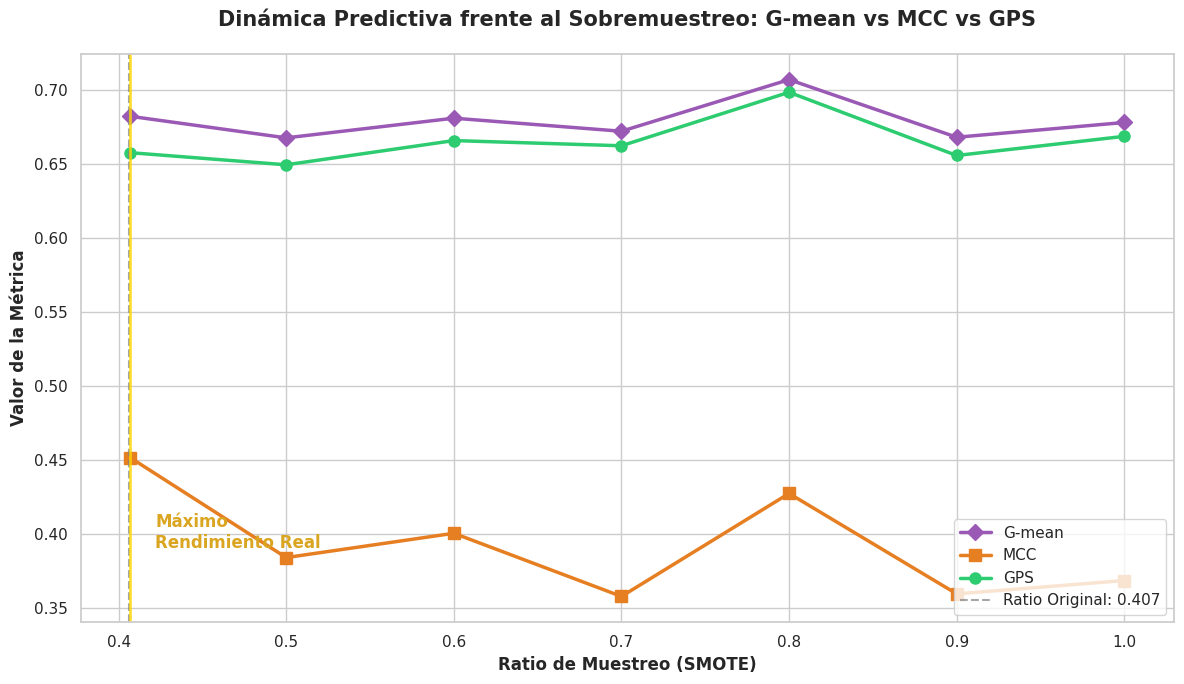

In [12]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(df_resultados.index, df_resultados['G-mean'], marker='D', color='#9b59b6', linewidth=2.5, markersize=8, label='G-mean')
ax.plot(df_resultados.index, df_resultados['MCC'], marker='s', color='#e67e22', linewidth=2.5, markersize=8, label='MCC')
ax.plot(df_resultados.index, df_resultados['GPS'], marker='o', color='#2ecc71', linewidth=2.5, markersize=8, label='GPS')

# Marcar el ratio original
ax.axvline(x=ratio_original, color='gray', linestyle='--', alpha=0.7, label=f'Ratio Original: {ratio_original:.3f}')

# Encontrar el punto máximo del MCC para marcar el "Verdadero Óptimo"
mejor_ratio_mcc = df_resultados['MCC'].idxmax()
ax.axvline(x=mejor_ratio_mcc, color='gold', linestyle='-', linewidth=2, alpha=0.8)
ax.text(mejor_ratio_mcc + 0.015, ax.get_ylim()[0] + 0.05, 'Máximo\nRendimiento Real', color='goldenrod', fontweight='bold')

ax.set_title('Dinámica Predictiva frente al Sobremuestreo: G-mean vs MCC vs GPS', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Ratio de Muestreo (SMOTE)', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la Métrica', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

In [19]:
# Definir los muestreadores a evaluar (Las tres naves de la flota)
samplers_dict = {
    'SMOTE': SMOTE,
    'ADASYN': ADASYN,
    'ROS': RandomOverSampler
}

ratios_a_probar = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
resultados_totales = []

# Evaluar el modelo Original (Baseline sin sobremuestreo)
gmean_orig, mcc_orig, gps_orig = evaluar_rendimiento_predictivo(X_train, y_train)

# Bucle principal para todos los muestreadores
for nombre_sampler, SamplerClass in samplers_dict.items():
    # Añadir siempre la línea base a cada algoritmo
    resultados_totales.append({
        'Sampler': nombre_sampler,
        'Ratio': round(ratio_original, 3),
        'G-mean': gmean_orig,
        'MCC': mcc_orig,
        'GPS': gps_orig
    })
    
    for r in ratios_a_probar:
        try:
            sampler = SamplerClass(sampling_strategy=r, random_state=42)
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            
            g, m, gp = evaluar_rendimiento_predictivo(X_res, y_res)
            resultados_totales.append({
                'Sampler': nombre_sampler,
                'Ratio': r,
                'G-mean': g,
                'MCC': m,
                'GPS': gp
            })
        except Exception as e:
            # Pasa de largo si ADASYN falla por pocos vecinos en una iteración
            pass

df_todos_resultados = pd.DataFrame(resultados_totales)

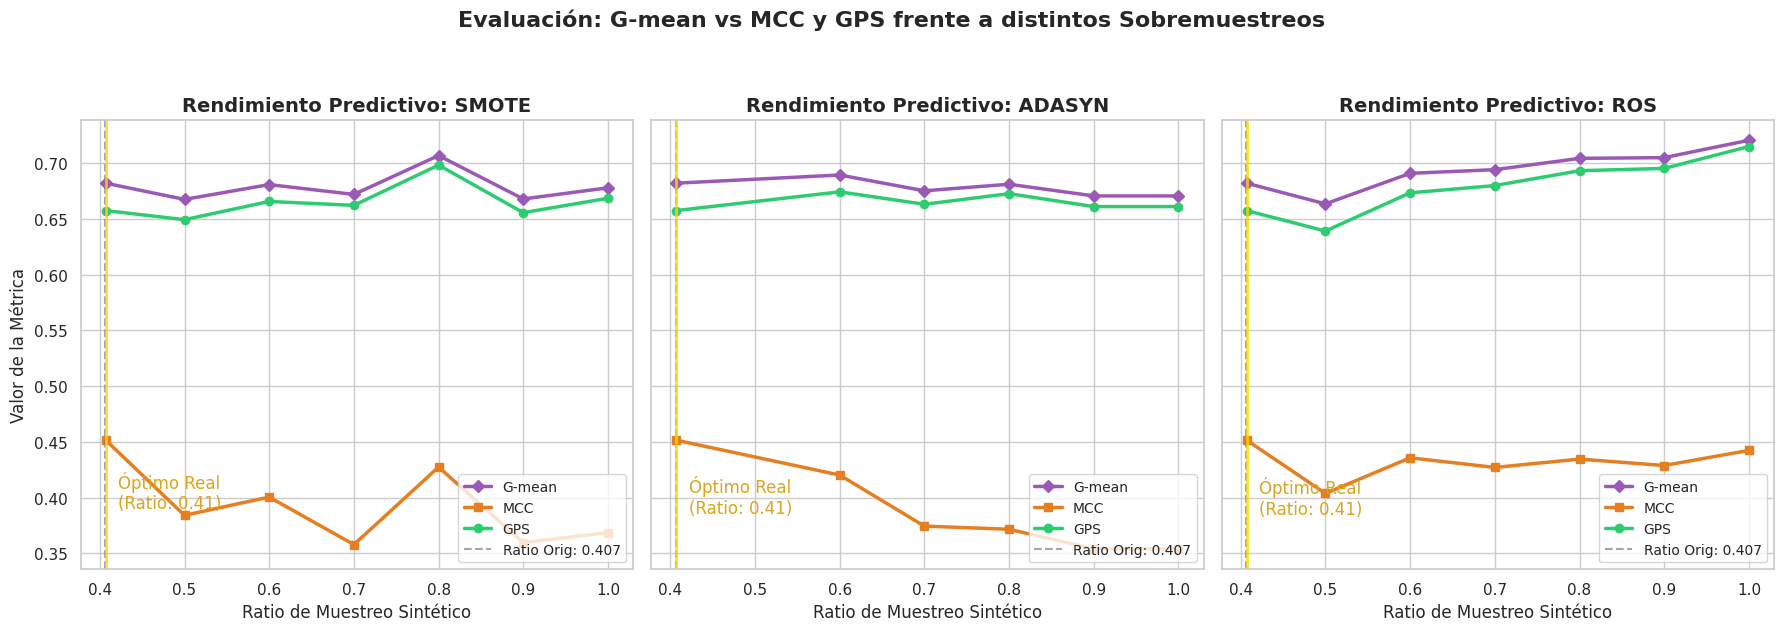

In [21]:
# Configurar panel de control: 1 fila, 3 columnas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
nombres_samplers = ['SMOTE', 'ADASYN', 'ROS']

for i, nombre in enumerate(nombres_samplers):
    ax = axes[i]
    df_sub = df_todos_resultados[df_todos_resultados['Sampler'] == nombre].reset_index(drop=True)
    
    # Trazar las métricas
    ax.plot(df_sub['Ratio'], df_sub['G-mean'], marker='D', color='#9b59b6', linewidth=2.5, label='G-mean')
    ax.plot(df_sub['Ratio'], df_sub['MCC'], marker='s', color='#e67e22', linewidth=2.5, label='MCC')
    ax.plot(df_sub['Ratio'], df_sub['GPS'], marker='o', color='#2ecc71', linewidth=2.5, label='GPS')
    
    # Marcar el ratio original (Baseline)
    ax.axvline(x=ratio_original, color='gray', linestyle='--', alpha=0.7, label=f'Ratio Orig: {ratio_original:.3f}')
    
    # Encontrar y marcar el "Verdadero Óptimo" dictado por el MCC
    mejor_idx = df_sub['MCC'].idxmax()
    mejor_ratio_mcc = df_sub.loc[mejor_idx, 'Ratio']
    ax.axvline(x=mejor_ratio_mcc, color='gold', linestyle='-', linewidth=2, alpha=0.8)
    
    ax.text(mejor_ratio_mcc + 0.015, ax.get_ylim()[0] + 0.05, f'Óptimo Real\n(Ratio: {mejor_ratio_mcc:.2f})', color='goldenrod')
    
    # Textos y leyendas
    ax.set_title(f'Rendimiento Predictivo: {nombre}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio de Muestreo Sintético', fontsize=12)
    if i == 0:
        ax.set_ylabel('Valor de la Métrica', fontsize=12)
    ax.legend(loc='lower right', fontsize=10, frameon=True)

plt.suptitle('Evaluación: G-mean vs MCC y GPS frente a distintos Sobremuestreos', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [22]:
# Crear una lista para almacenar el resumen táctico
resumen = []

# Extraer el rendimiento original (Baseline) que es igual para todos
baseline = df_todos_resultados[df_todos_resultados['Ratio'] == round(ratio_original, 3)].iloc[0]

resumen.append({
    'Método': 'Baseline (Original)',
    'Ratio Óptimo': baseline['Ratio'],
    'MCC Máximo': baseline['MCC'],
    'GPS': baseline['GPS'],
    'G-mean': baseline['G-mean']
})

# Extraer el punto óptimo (basado en el máximo MCC) para cada algoritmo
for nombre in nombres_samplers:
    df_sub = df_todos_resultados[df_todos_resultados['Sampler'] == nombre]
    
    mejor_idx = df_sub['MCC'].idxmax()
    fila_optima = df_sub.loc[mejor_idx]
    
    resumen.append({
        'Método': nombre,
        'Ratio Óptimo': fila_optima['Ratio'],
        'MCC Máximo': fila_optima['MCC'],
        'GPS': fila_optima['GPS'],
        'G-mean': fila_optima['G-mean']
    })

# Convertir a DataFrame y mostrar con formato visual
df_resumen = pd.DataFrame(resumen)

# Darle un poco de estilo resaltando los valores más altos en verde
formato_tabla = df_resumen.style.highlight_max(
    subset=['MCC Máximo', 'GPS', 'G-mean'], 
    color='lightgreen', 
    axis=0
).format({
    'Ratio Óptimo': '{:.3f}',
    'MCC Máximo': '{:.4f}',
    'GPS': '{:.4f}',
    'G-mean': '{:.4f}'
}).set_properties(**{'text-align': 'center', 'font-weight': 'bold'})

display(formato_tabla)

,Método,Ratio Óptimo,MCC Máximo,GPS,G-mean
0,Baseline (Original),0.407,0.4515,0.6576,0.6821
1,SMOTE,0.407,0.4515,0.6576,0.6821
2,ADASYN,0.407,0.4515,0.6576,0.6821
3,ROS,0.407,0.4515,0.6576,0.6821
